In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import gamma


# 1. Exploratory Data Analysis

In [19]:
df=pd.read_csv("data/train.csv")
df.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Select relevant variables

In [20]:
df_train = df[["MONTH", "DAY_OF_WEEK", "DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND"]]
df_train=df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})
df_train.to_csv("data/train_filter.csv", index=False)
print(f"Number of observations: {len(df_train)}")
df_train.head()

Number of observations: 4542343


,MONTH,DAY_OF_WEEK,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND
0,7,7,0,26,American Airlines Inc.,0.00,4.25
1,4,1,0,63,SkyWest Airlines Inc.,0.00,11.41
2,11,4,0,3,American Eagle Airlines Inc.,0.00,0.45
3,3,2,0,14,Southwest Airlines Co.,0.00,8.05
4,7,3,0,85,American Eagle Airlines Inc.,0.01,10.51


In [21]:
print(df_train.isna().sum())

MONTH                 0
DAY_OF_WEEK           0
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
dtype: int64


## 1.2. Categorical Variables

### Month

In [22]:
df_train["MONTH"].value_counts().sort_index()

MONTH
1     351390
2     315785
3     387505
4     373800
5     390479
6     389812
7     404984
8     406093
9     370721
10    393106
11    372259
12    386409
Name: count, dtype: int64

### Day of Week

In [23]:
df_train["DAY_OF_WEEK"].value_counts().sort_index()

DAY_OF_WEEK
1    676815
2    662339
3    656193
4    669146
5    678895
6    552926
7    646029
Name: count, dtype: int64

### Delay (Class)

Classes are not balanced

In [24]:
df_train["DELAY"].value_counts().sort_index()

DELAY
0    3683185
1     859158
Name: count, dtype: int64

### Carrier

In [25]:
df_train["CARRIER_NAME"].value_counts()

CARRIER_NAME
Southwest Airlines Co.          907076
Delta Air Lines Inc.            657062
American Airlines Inc.          632771
United Air Lines Inc.           420624
SkyWest Airlines Inc.           409126
Midwest Airline, Inc.           210298
JetBlue Airways                 188402
Alaska Airlines Inc.            167595
American Eagle Airlines Inc.    160390
Comair Inc.                     153365
Endeavor Air Inc.               142498
Spirit Air Lines                132678
Mesa Airlines Inc.              124171
Frontier Airlines Inc.           84970
Atlantic Southeast Airlines      69161
Hawaiian Airlines Inc.           52444
Allegiant Air                    29712
Name: count, dtype: int64

## 1.3. Non Categorical Variables

### Concurrent Flights

Looks Half Normal

Maximum value of concurrent flights: 109
Minimum value of concurrent flights: 1


(array([599940., 636825., 593137., 433025., 447092., 457009., 230487.,
        216521., 148400., 120230., 172017., 129255., 111502.,  69312.,
         70553.,  66068.,  30085.,   6809.,   1162.,   2914.]),
 array([  1. ,   6.4,  11.8,  17.2,  22.6,  28. ,  33.4,  38.8,  44.2,
         49.6,  55. ,  60.4,  65.8,  71.2,  76.6,  82. ,  87.4,  92.8,
         98.2, 103.6, 109. ]),
 <BarContainer object of 20 artists>)

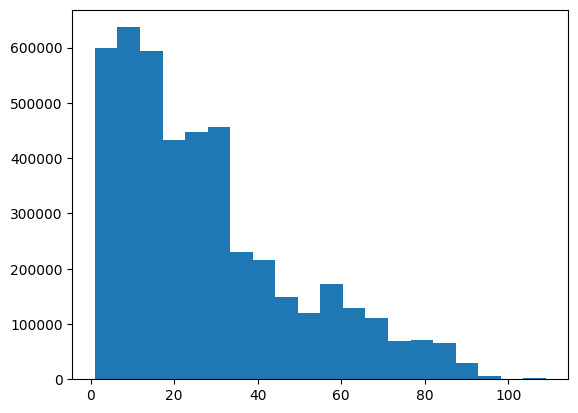

In [26]:
print(f"Maximum value of concurrent flights: {df_train["CONCURRENT_FLIGHTS"].max()}")
print(f"Minimum value of concurrent flights: {df_train["CONCURRENT_FLIGHTS"].min()}")

cflights=df_train["CONCURRENT_FLIGHTS"].values
plt.hist(cflights, bins=20)

### Rain

Maximum value of precipitation: 11.63
Minimum value of precipitation: 0.0
Proportion of zero rain days: 0.7020665326242426
Mean (all days): 0.10368144809848133
Mean (rainy days only): 0.34800201874506764


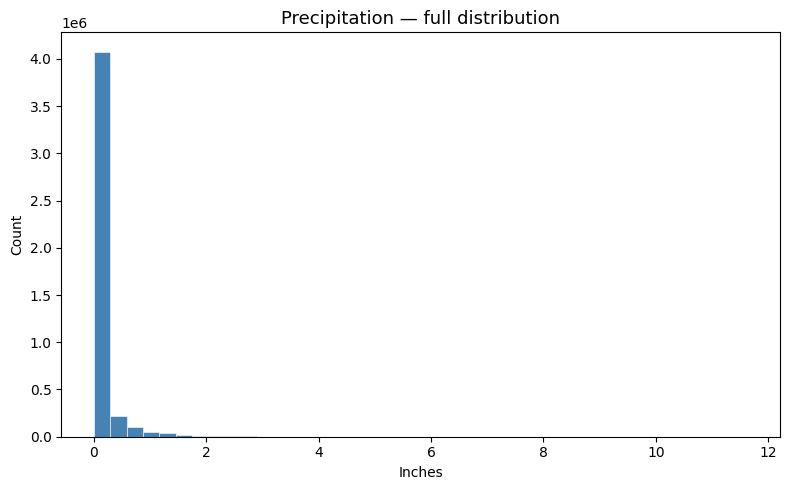

In [41]:
prcp = df_train["PRCP"].values

print(f"Maximum value of precipitation: {df_train['PRCP'].max()}")
print(f"Minimum value of precipitation: {df_train['PRCP'].min()}")
print(f"Proportion of zero rain days: {(df_train['PRCP'] == 0).mean()}")
print(f"Mean (all days): {df_train['PRCP'].mean()}")
print(f"Mean (rainy days only): {df_train[df_train['PRCP'] > 0]['PRCP'].mean()}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(prcp, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Precipitation — full distribution', fontsize=13)
ax.set_xlabel('Inches')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

       mean_rain  nonzero_count  total_count  prop_rainy
MONTH                                                   
1       0.098798         103609       351390    0.294855
2       0.110854         135958       315785    0.430540
3       0.072606         107945       387505    0.278564
4       0.111493         123681       373800    0.330875
5       0.130815         140144       390479    0.358903
6       0.135434         131781       389812    0.338063
7       0.096119          96597       404984    0.238521
8       0.105957         104622       406093    0.257631
9       0.077970          71933       370721    0.194035
10      0.120232         116345       393106    0.295963
11      0.065399          98477       372259    0.264539
12      0.116662         122224       386409    0.316307


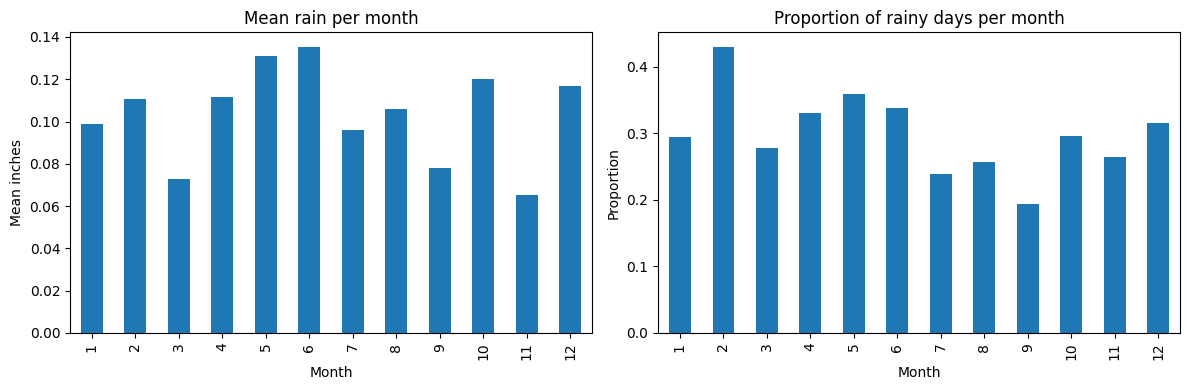

In [ ]:
# mean rain per month
rain_per_month = df.groupby('MONTH')['PRCP'].mean()

# number of non-zero rain observations per month
nonzero_per_month = df[df['PRCP'] > 0].groupby('MONTH')['PRCP'].count()

# total observations per month (to compute proportion)
total_per_month = df.groupby('MONTH')['PRCP'].count()

# proportion of rainy days per month
prop_rainy = nonzero_per_month / total_per_month

summary = pd.DataFrame({
    'mean_rain': rain_per_month,
    'nonzero_count': nonzero_per_month,
    'total_count': total_per_month,
    'prop_rainy': prop_rainy
})

print(summary)

# plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rain_per_month.plot(kind='bar', ax=axes[0], title='Mean rain per month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean inches')

prop_rainy.plot(kind='bar', ax=axes[1], title='Proportion of rainy days per month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

### Wind

Maximum value of wind: 33.78
Minimum value of wind: 0.0


(array([1.48870e+04, 1.98091e+05, 5.77473e+05, 9.40026e+05, 8.65017e+05,
        7.49674e+05, 4.70822e+05, 3.26904e+05, 1.69936e+05, 1.13152e+05,
        5.87890e+04, 2.73220e+04, 1.69360e+04, 6.94800e+03, 3.43000e+03,
        1.65800e+03, 1.03100e+03, 4.40000e+01, 6.20000e+01, 1.41000e+02]),
 array([ 0.   ,  1.689,  3.378,  5.067,  6.756,  8.445, 10.134, 11.823,
        13.512, 15.201, 16.89 , 18.579, 20.268, 21.957, 23.646, 25.335,
        27.024, 28.713, 30.402, 32.091, 33.78 ]),
 <BarContainer object of 20 artists>)

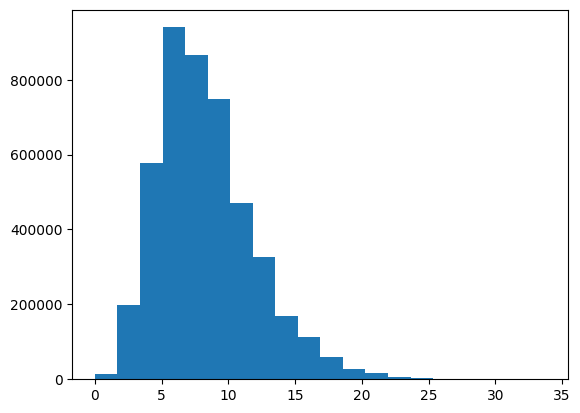

In [28]:
print(f"Maximum value of wind: {df_train["WIND"].max()}")
print(f"Minimum value of wind: {df_train["WIND"].min()}")

wind=df_train["WIND"].values
plt.hist(wind, bins=20)

# 2. Chosen distributions

- PRCP
- WIND
- DELAY 
- CONCURRENT_FLIGHTS
- CARRIER_NAME


### Rain

- Zero inflated distribution for Gamma distribution
- Fit parameters per month from data

In [46]:
rain_params = {}
for month in range(1, 13):
    month_data = df_train[df_train['MONTH'] == month]['PRCP']

    # proportion of no-rain days
    pi_m = (month_data == 0).mean()

    # fit gamma on rain days only
    wet_days = month_data[month_data > 0]
    alpha_m, _, beta_m = gamma.fit(wet_days, floc=0)

    rain_params[month] = {
        'pi': torch.tensor(pi_m,    dtype=torch.float32),
        'alpha': torch.tensor(alpha_m, dtype=torch.float32),
        'beta': torch.tensor(beta_m,  dtype=torch.float32)
    }